## EQUAZIONI DI RICORRENZA

In [4]:
'Import main libraries'
import numpy as np
import time
import matplotlib.pyplot as plt

### Algoritmi FATTORIALE

Algoritmo Iterativo :  0.000136  [secs]
Algoritmo Ricorsivo :  0.00112  [secs]


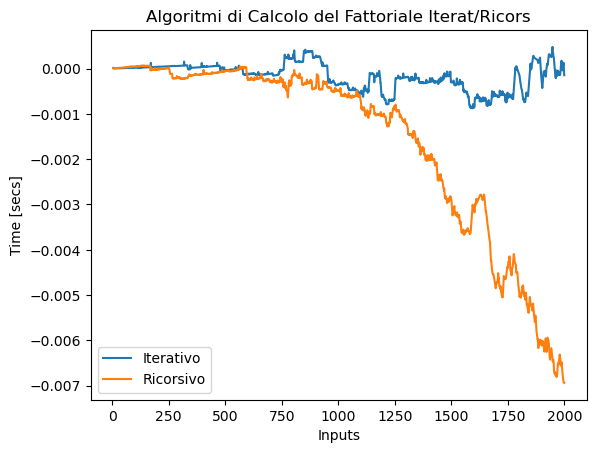

In [5]:
# LA RICORSIONE

'''
CALCOLO del FATTORIALE
Il calcolo del fattoriale puo' essere eseguito tramite un algoritmo ITERATIVO
ma anche tramite un algoritmo RICORSIVO'''

# Algoritmo ITERATIVO

def fattorialeIterativo(n):
    fatt=1                      #Θ(1)
    for i in range(1,n+1):      #n*Θ(1)+Θ(1)
        fatt=fatt*i             #Θ(1)
    return fatt                 #Θ(1)

# Dimensione input: valore intero n
# Caso migliore e caso peggiore coincidono per qualsiasi valore grande
# di n dato che l'algoritmo scorre sempre e cmq tutti i valori da 1 a n.
# Costo Computazionale: T(n)=Θ(1)+Θ(n)+Θ(1)=Θ(n)

# Algoritmo RICORSIVO

def fattorialeRicorsivo(n):
    if n==1:                              #Θ(1)     'Caso Base'
        return 1                          #Θ(1)     
    else:                                 #Θ(1)
        return n*fattorialeRicorsivo(n-1) # T(n-1)  'Passo Ricorsivo'

# Dimensione input: valore intero n
# Costo Computazionale: T(n)=Θ(1)+T(n-1) -> Equazioni di Ricorrenza


n=61

tic=time.perf_counter()
fattIter=fattorialeIterativo(n)
toc=time.perf_counter()
fattIterTime=round(toc-tic,6)

tic=time.perf_counter()
fattRicors=fattorialeRicorsivo(n)
toc=time.perf_counter()
fattRicorsTime=round(toc-tic,6)

print('Algoritmo Iterativo : ',fattIterTime, ' [secs]')
print('Algoritmo Ricorsivo : ',fattRicorsTime, ' [secs]')




# RAPPRESENTAZIONE GRAFICA


def rappresentazioneGrafica(data_x,data_y,tolerance,title,legendLabel):
    
    delta_max = tolerance # maximum difference in y between two points
    delta = 0 # running correction value
    data_cor = [] # corrected array
    data_cor.append(data_y[0])   # we append two first points
    data_cor.append(data_y[1])
    i=0
    
    for i in range(0,len(data_x)-2): # two first points are allready appended
        i += 2
        delta_i = data_y[i] - data_y[i-1]
        if np.abs(delta_i) > delta_max:
            delta += (delta_i - (data_cor[i-1] - data_cor[i-2]))
            data_cor.append(data_y[i]-delta)
        else:
            data_cor.append(data_y[i]-delta)
    
    
    plt.plot(data_x, data_cor,label=legendLabel)
    
    plt.xlabel('Inputs')
    plt.ylabel('Time [secs]')
    plt.legend()
    plt.title(title)




stepsA=[]
for i in range(5,2000):
    tic=time.perf_counter()
    fattorialeIterativo(i)
    toc=time.perf_counter()
    stepsA.append(round(abs(toc-tic),12))


stepsB=[]
for i in range(5,2000):
    tic=time.perf_counter()
    fattorialeRicorsivo(i)
    toc=time.perf_counter()
    stepsB.append(round(abs(toc-tic),12))

    
rappresentazioneGrafica(range(5,2000),stepsA,0.0001,"Algoritmi di Calcolo "  
                        "del Fattoriale Iterat/Ricors","Iterativo")

rappresentazioneGrafica(range(5,2000),stepsB,0.0001,"Algoritmi di Calcolo " 
                       "del Fattoriale Iterat/Ricors","Ricorsivo")

### Algoritmi RICORSIVI di RICERCA

Algoritmo di Ricerca Sequenziale Ricorsivo :  2003500  [nanosecs]
Algoritmo di Ricerca Binaria Ricorsivo :  133000  [nanosecs]


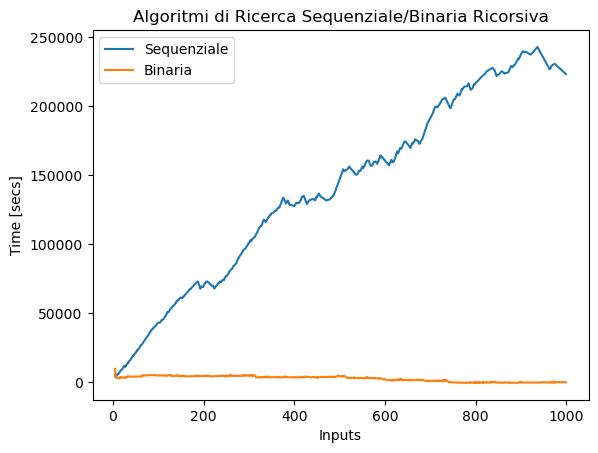

In [6]:
# LA RICORSIONE

'''
ALGORITMI di RICERCA RICORSIVA
Sia la ricerca SEQUENZIALE sia la ricerca BINARIA possono essere definite
tramite algoritmi RICORSIVI'''

# Algoritmo RICORSIVO di RICERCA SEQUENZIALE

def ricercaSequenzialeRicorsiva(A,v,i):
    if A[i]==v:                                    # Θ(1)   'Caso Base 1
        return i                                   # Θ(1) 
    elif i>=len(A):                                # Θ(1)   'Caso Base 2 
        return -1                                  # Θ(1) 
    else:                                          # Θ(1) 
        i+=1                                       # Θ(1) 
        return ricercaSequenzialeRicorsiva(A,v,i)  # T(n-1) 'Passo Ricorsivo
    

# Dimensione input: numero n di elementi nell'array A
# Caso migliore e caso peggiore variano a seconda che l'elemento cercato v
# si trovi nella prima cella dell'array A o non esista affatto.
# Costo Computazionale: T(n)=Θ(1)+T(n-1)


# Alternativamente...si possono utilizzare due funzioni, una interna all'altra
# di cui solo quella interna e' ricorsiva

def ricercaSequenziale(A,v):
    'Chiamata di lancio della Ricorsione'
    return ricercaSequenzialeRicorsiva(A,v,len(A)-1) #T(n)
    
def ricercaSequenzialeRicorsiva(A,v,n):
    if A[n]==v:                                     # Θ(1)   'Caso Base 1
        return True                                 # Θ(1) 
    elif n==0:                                      # Θ(1)   'Caso Base 2 
        return False                                # Θ(1) 
    else:                                           # Θ(1) 
        return ricercaSequenzialeRicorsiva(A,v,n-1) # T(n-1) 'Passo Ricorsivo





# Algoritmo RICORSIVO di RICERCA BINARIA

def ricercaBinaria(A,v):
    a,b=0,len(A)-1                                   # Θ(1)
    return ricercaBinariaRicorsiva(A,v,a,b)          # T(n)
    
def ricercaBinariaRicorsiva(A,v,a,b):
    m=(a+b)//2                                       # Θ(1)
    if a>b:                                          # Θ(1)   'Caso Base 1
        return False                                 # Θ(1)
    if A[m]==v:                                      # Θ(1)   'Caso Base 2
        return True                                  # Θ(1)
    if A[m]<v:                                       # Θ(1)
        return ricercaBinariaRicorsiva(A, v, m+1, b) # T(n/2) 'Passo Ricorsivo
    if A[m]>v:                                       # Θ(1)
        return ricercaBinariaRicorsiva(A, v, a, m-1) # T(n/2)


# Dimensione input: numero n di elementi nell'array A
# Caso migliore e caso peggiore variano a seconda che il valore cercato
# sia a meta' dell'array ordinato A (Ω(1)) o non sia affatto presente
# all'interno dell'array A (O(logn))
# Costo Computazionale: T(n)=Θ(1)+T(n/2) -> Equazioni di Ricorrenza



v=1
A=range(1,1000)

tic=time.perf_counter_ns()
found=ricercaSequenziale(A,v)
toc=time.perf_counter_ns()
seqRicTime=round(toc-tic,6)

tic=time.perf_counter_ns()
found=ricercaBinaria(A,v)
toc=time.perf_counter_ns()
binRicTime=round(toc-tic,6)

print('Algoritmo di Ricerca Sequenziale Ricorsivo : ',seqRicTime,' [nanosecs]')
print('Algoritmo di Ricerca Binaria Ricorsivo : ',binRicTime,' [nanosecs]')



# RAPPRESENTAZIONE GRAFICA


def rappresentazioneGrafica(data_x,data_y,tolerance,title,legendLabel):
    
    delta_max = tolerance # maximum difference in y between two points
    delta = 0 # running correction value
    data_cor = [] # corrected array
    data_cor.append(data_y[0])   # we append two first points
    data_cor.append(data_y[1])
    i=0
    
    for i in range(0,len(data_x)-2): # two first points are allready appended
        i += 2
        delta_i = data_y[i] - data_y[i-1]
        if np.abs(delta_i) > delta_max:
            delta += (delta_i - (data_cor[i-1] - data_cor[i-2]))
            data_cor.append(data_y[i]-delta)
        else:
            data_cor.append(data_y[i]-delta)
    
    
    plt.plot(data_x, data_cor,label=legendLabel)
    
    plt.xlabel('Inputs')
    plt.ylabel('Time [secs]')
    plt.legend()
    plt.title(title)



stepsA=[]
for i in range(5,1000):
    A=list(range(1,i))
    v=i
    tic=time.perf_counter_ns()
    found=ricercaSequenziale(A,v)
    toc=time.perf_counter_ns()
    stepsA.append(round(toc-tic,6))


stepsB=[]
for i in range(5,1000):
    B=list(range(1,i))
    v=i
    tic=time.perf_counter_ns()
    found=ricercaBinaria(B,v)
    toc=time.perf_counter_ns()
    stepsB.append(round(toc-tic,6))

    
rappresentazioneGrafica(range(5,1000),stepsA,1000,"Algoritmi di Ricerca "  
                        "Sequenziale/Binaria Ricorsiva","Sequenziale")

rappresentazioneGrafica(range(5,1000),stepsB,1000,"Algoritmi di Ricerca "  
                        "Sequenziale/Binaria Ricorsiva","Binaria")

### Algoritmi Calcolo di Fibonacci 

Per n= 13  il numero di Fibonacci e' pari a  
Algoritmo Iterativo:  233 
Algoritmo Ricorsivo:  233
Algoritmo Iterativo :  131700  [nanosecs]
Algoritmo Ricorsivo :  401012700  [nanosecs]


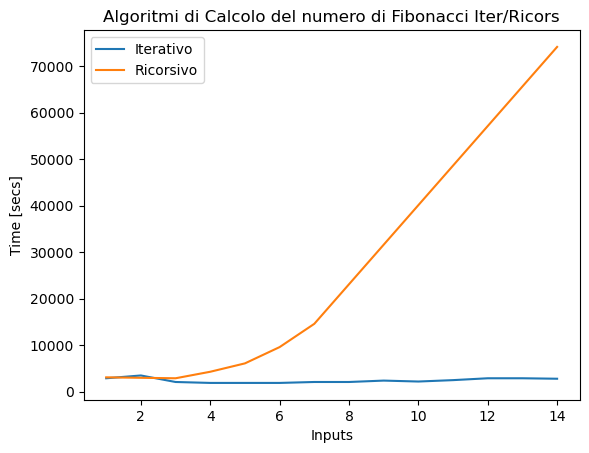

In [7]:

# LA RICORSIONE

'''
CALCOLO NUMERO DI FIBONACCI
Il calcolo del numero di Fibonacci e' un problema prettamente ricorsivo.
E' possibile, pero', risolverlo anche con un processo iterativo. 
Confrontiamo i due algoritmi'''

# Algoritmo RICORSIVO di FIBONACCI

def fibRicorsivo(n):
    if n==0 or n==1:                                # Θ(1) 'Casi Base
        return n                                    # Θ(1)
    else:                                           # Θ(1) 'Passo Ricorsivo
        return fibRicorsivo(n-1)+fibRicorsivo(n-2)  # T(n-1)+T(n-2)


# Dimensione input: valore del numero n
# Caso migliore e caso peggiore coincidono per valori grandi di n (gli unici
# validi per il calcolo di notazione asintotica).
# Costo Computazionale: T(n)=Θ(1)+T(n-1)+T(n-2) -> Equazioni di Ricorrenza



# Algoritmo ITERATIVO di FIBONACCI

def fibIterativo(n):
    if n<=1:                             # Θ(1)
        return n                         # Θ(1)
    fib0,fib1,fib=0,1,0                  # Θ(1)
    for i in range(2,n+1):               # n*Θ(1)+Θ(1)
        fib=fib0+fib1                    # Θ(1)
        fib0,fib1=fib1,fib               # Θ(1)
    return fib                           # Θ(1)

# Dimensione input: valore del numero n
# Caso migliore e caso peggiore coincidono per valori grandi di n (gli unici
# validi per il calcolo di notazione asintotica).
# Costo Computazionale: T(n)=Θ(1)+n*Θ(1)+Θ(1)=Θ(n)    

n=13
fibIt=fibIterativo(n)
fibRic=fibRicorsivo(n)

print("Per n=",n," il numero di Fibonacci e' pari a ",
      "\nAlgoritmo Iterativo: ", fibIt,"\nAlgoritmo Ricorsivo: ", fibRic)


n=28

tic=time.perf_counter_ns()
fibIt=fibIterativo(n)
toc=time.perf_counter_ns()
fibItTime=round(toc-tic,6)

tic=time.perf_counter_ns()
fibRic=fibRicorsivo(n)
toc=time.perf_counter_ns()
fibRicTime=round(toc-tic,6)

print('Algoritmo Iterativo : ',fibItTime,' [nanosecs]')
print('Algoritmo Ricorsivo : ',fibRicTime,' [nanosecs]')



# CONFRONTO ALGORITMO RICORSIVO/ITERATIVO
'''
L'algoritmo RICORSIVO e' molto meno efficiente dell'algoritmo
ITERATIVO. Sia in termini di TIME che di SPACE COMPLEXITY!!
'''


# RAPPRESENTAZIONE GRAFICA


def rappresentazioneGrafica(data_x,data_y,tolerance,title,legendLabel):
    
    delta_max = tolerance # maximum difference in y between two points
    delta = 0 # running correction value
    data_cor = [] # corrected array
    data_cor.append(data_y[0])   # we append two first points
    data_cor.append(data_y[1])
    i=0
    
    for i in range(0,len(data_x)-2): # two first points are allready appended
        i += 2
        delta_i = data_y[i] - data_y[i-1]
        if np.abs(delta_i) > delta_max:
            delta += (delta_i - (data_cor[i-1] - data_cor[i-2]))
            data_cor.append(data_y[i]-delta)
        else:
            data_cor.append(data_y[i]-delta)
    
    
    plt.plot(data_x, data_cor,label=legendLabel)
    
    plt.xlabel('Inputs')
    plt.ylabel('Time [secs]')
    plt.legend()
    plt.title(title)



stepsA=[]
for i in range(1,15):
    tic=time.perf_counter_ns()
    fibIt=fibIterativo(i)
    toc=time.perf_counter_ns()
    stepsA.append(round(toc-tic,6))


stepsB=[]
for i in range(1,15):
    tic=time.perf_counter_ns()
    fibRic=fibRicorsivo(i)
    toc=time.perf_counter_ns()
    stepsB.append(round(toc-tic,6))

    
rappresentazioneGrafica(range(1,15),stepsA,10000,"Algoritmi di Calcolo "  
                        "del numero di Fibonacci Iter/Ricors","Iterativo")

rappresentazioneGrafica(range(1,15),stepsB,10000,"Algoritmi di Calcolo "  
                        "del numero di Fibonacci Iter/Ricors","Ricorsivo")